In [29]:
!pip install pandas
!pip install kagglehub

In [4]:
import pandas as pd
import kagglehub
import sqlite3

In [5]:
"""
Use kagglehub library to download dataset.
"""

KAGGLE_DATASET_URL = 'dandanjia/vgsales-csv'
kagglehub.dataset_download(KAGGLE_DATASET_URL)

100%|██████████| 381k/381k [00:00<00:00, 71.6MB/s]

Extracting files...


'/root/.cache/kagglehub/datasets/dandanjia/vgsales-csv/versions/1'

In [6]:
"""
Load dataset into pandas dataframe.
"""

file_path = '/root/.cache/kagglehub/datasets/dandanjia/vgsales-csv/versions/1/vgsales.csv'
df = pd.read_csv(file_path)

In [7]:
"""
Looking at the dataset by year, we can see that the density of data points is highest in the late 2000s. Our analysis will focus on this time period to ensure that we have enough data points to draw meaningful conclusions.
"""

df = df.sort_values(by='Year')
df['Year'].value_counts().sort_index()

,count
Year,
1980.0,9
1981.0,46
1982.0,36
1983.0,17
1984.0,14
1985.0,14
1986.0,21
1987.0,16
1988.0,15


In [8]:
"""
To further focus our analysis, we want to find the top three publishers with the highest global sales.
"""

top_three = df.groupby('Publisher').sum().sort_values('Global_Sales', ascending=False).head(3)
top_three = top_three.reset_index()
top_three = top_three[['Publisher', 'Global_Sales']]

print(top_three)

         Publisher  Global_Sales
0         Nintendo       1786.56
1  Electronic Arts       1110.32
2       Activision        727.46


In [9]:
"""
For our analysis, we will filter the data to only include the top three publishers and year range between 2000 and 2016
"""

top_three_publishers = top_three['Publisher'].tolist()
years = list(range(2000, 2017))
filtered_df = df[(df['Publisher'].isin(top_three_publishers)) & (df['Year'].isin(years))]

print(filtered_df)

        Rank                                  Name Platform    Year    Genre  \
2930    2932                    NCAA Football 2001       PS  2000.0   Sports   
9932    9934            Mobil 1 Rally Championship       PS  2000.0   Racing   
3586    3588                         NASCAR Rumble       PS  2000.0   Racing   
3794    3796                            Spider-Man      N64  2000.0   Action   
2247    2249          007: The World is not Enough       PS  2000.0   Action   
...      ...                                   ...      ...     ...      ...   
4350    4352  Plants vs. Zombies: Garden Warfare 2      PS4  2016.0  Shooter   
5056    5058                               FIFA 17      PS3  2016.0   Sports   
15804  15807  Call of Duty: Modern Warfare Trilogy     X360  2016.0  Shooter   
4658    4660                       Hyrule Warriors      3DS  2016.0   Action   
4820    4822                       EA Sports UFC 2     XOne  2016.0   Sports   

             Publisher  NA_Sales  EU_Sa

In [10]:
"""
For visualization, we will need to group the data by year and publisher. We will sum the sales for each year and counts of the other relevant fields.
"""

grouped_df = filtered_df.groupby(['Year', 'Publisher']).agg({
    'Global_Sales': 'sum',
    'NA_Sales': 'sum',
    'EU_Sales': 'sum',
    'JP_Sales': 'sum',
    'Other_Sales': 'sum',
    'Name': 'nunique',
    'Platform': 'nunique',
    'Genre': 'nunique'
}).reset_index()

print(grouped_df)

      Year        Publisher  Global_Sales  NA_Sales  EU_Sales  JP_Sales  \
0   2000.0       Activision         14.48      9.31      4.50      0.05   
1   2000.0  Electronic Arts         25.13     15.09      7.14      1.23   
2   2000.0         Nintendo         34.05     15.00      6.42     10.53   
3   2001.0       Activision         18.59     10.96      6.19      0.17   
4   2001.0  Electronic Arts         45.12     26.21     14.46      0.47   
5   2001.0         Nintendo         45.37     23.84      8.84     11.15   
6   2002.0       Activision         25.94     16.34      7.75      0.12   
7   2002.0  Electronic Arts         73.01     40.70     24.37      0.93   
8   2002.0         Nintendo         48.31     25.05      9.89     11.90   
9   2003.0       Activision         21.38     13.16      6.40      0.28   
10  2003.0  Electronic Arts         69.83     40.47     21.11      2.38   
11  2003.0         Nintendo         38.14     20.15      7.08      9.85   
12  2004.0       Activisi

In [11]:
"""
The sum, max, min, mean, standard deviation, and count by Platform.
"""
grouped_df = filtered_df.groupby(['Platform']).agg({
    'Global_Sales': ['sum', 'max', 'min', 'mean', 'std', 'count'],
    'NA_Sales': ['sum', 'max', 'min', 'mean', 'std', 'count'],
    'EU_Sales': ['sum', 'max', 'min', 'mean', 'std', 'count'],
    'JP_Sales': ['sum', 'max', 'min', 'mean', 'std', 'count'],
    'Other_Sales': ['sum', 'max', 'min', 'mean', 'std', 'count']
}).reset_index()

grouped_df[('Global_Sales', 'range')] = grouped_df[('Global_Sales', 'max')] - grouped_df[('Global_Sales', 'min')]
grouped_df[('NA_Sales', 'range')] = grouped_df[('NA_Sales', 'max')] - grouped_df[('NA_Sales', 'min')]
grouped_df[('EU_Sales', 'range')] = grouped_df[('EU_Sales', 'max')] - grouped_df[('EU_Sales', 'min')]
grouped_df[('JP_Sales', 'range')] = grouped_df[('JP_Sales', 'max')] - grouped_df[('JP_Sales', 'min')]
grouped_df[('Other_Sales', 'range')] = grouped_df[('Other_Sales', 'max')] - grouped_df[('Other_Sales', 'min')]

grouped_df = grouped_df.sort_values(by=[('Global_Sales', 'sum'), ('NA_Sales', 'sum'), ('EU_Sales', 'sum'), ('JP_Sales', 'sum'), ('Other_Sales', 'sum')], ascending=False)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

print (grouped_df)


   Platform Global_Sales                                        NA_Sales  \
                     sum    max   min      mean       std count      sum   
13      Wii       512.51  82.74  0.01  1.836953  6.537635   279   257.73   
1        DS       423.86  30.01  0.01  1.254024  3.372801   338   166.85   
15     X360       336.72  14.76  0.01  1.129933  2.008994   298   211.45   
8       PS2       331.55   7.20  0.01  1.108863  1.268790   299   182.41   
9       PS3       293.48  14.03  0.01  1.178635  2.020239   249   125.92   
0       3DS       163.83  14.35  0.01  1.412328  2.636769   116    56.66   
3       GBA       141.61  15.85  0.01  0.786722  1.681919   180    73.12   
4        GC       119.62   7.07  0.03  0.646595  1.037764   185    77.18   
6        PC       104.63   8.11  0.01  0.542124  1.104445   193    38.56   
10      PS4        95.58  14.24  0.03  2.033617  2.865561    47    34.04   
16       XB        89.91   2.28  0.01  0.496740  0.447507   181    64.59   
14     WiiU 

In [26]:
# Create database and load dataframe into a new table 'top_publishers'
import sqlite3

con = sqlite3.connect('vgsales.db')
cur = con.cursor()
filtered_df.to_sql('top_publishers', con, if_exists='replace', index=False)

2666

In [28]:
# Check that table is correctly created in database
cur.execute("SELECT * FROM top_publishers;").fetchall()

[(2932,
  'NCAA Football 2001',
  'PS',
  2000.0,
  'Sports',
  'Electronic Arts',
  0.39,
  0.26,
  0.0,
  0.05,
  0.7),
 (9934,
  'Mobil 1 Rally Championship',
  'PS',
  2000.0,
  'Racing',
  'Electronic Arts',
  0.07,
  0.04,
  0.0,
  0.01,
  0.12),
 (3588,
  'NASCAR Rumble',
  'PS',
  2000.0,
  'Racing',
  'Electronic Arts',
  0.31,
  0.21,
  0.0,
  0.04,
  0.56),
 (3796,
  'Spider-Man',
  'N64',
  2000.0,
  'Action',
  'Activision',
  0.43,
  0.09,
  0.0,
  0.01,
  0.53),
 (2249,
  '007: The World is not Enough',
  'PS',
  2000.0,
  'Action',
  'Electronic Arts',
  0.51,
  0.35,
  0.0,
  0.06,
  0.92),
 (2929,
  'NASCAR 2001',
  'PS2',
  2000.0,
  'Racing',
  'Electronic Arts',
  0.34,
  0.27,
  0.0,
  0.09,
  0.7),
 (11925,
  'Itoi Shigesato no Bass Tsuri No. 1 Ketteihan!',
  'N64',
  2000.0,
  'Sports',
  'Nintendo',
  0.0,
  0.0,
  0.07,
  0.0,
  0.07),
 (4287,
  'Star Wars: Demolition',
  'PS',
  2000.0,
  'Racing',
  'Activision',
  0.25,
  0.17,
  0.0,
  0.03,
  0.46),
 (248

In [12]:
"""
The distribution by Platform. Next we can complete a visualization to find the outliers.
"""
distribution = filtered_df.groupby(['Platform']).describe()[['Global_Sales', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']]

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

print (distribution)


         Global_Sales                                                          \
                count      mean       std   min     25%    50%     75%    max   
Platform                                                                        
3DS             116.0  1.412328  2.636769  0.01  0.1550  0.435  1.3000  14.35   
DS              338.0  1.254024  3.372801  0.01  0.1400  0.290  0.7300  30.01   
GB               13.0  1.689231  1.565511  0.20  0.8900  1.330  1.9200   6.39   
GBA             180.0  0.786722  1.681919  0.01  0.1275  0.310  0.6925  15.85   
GC              185.0  0.646595  1.037764  0.03  0.1400  0.330  0.6600   7.07   
N64              28.0  0.985000  0.955078  0.06  0.1900  0.565  1.6050   3.36   
PC              193.0  0.542124  1.104445  0.01  0.0300  0.090  0.5100   8.11   
PS               36.0  0.994444  1.023128  0.09  0.3975  0.630  1.3450   4.68   
PS2             299.0  1.108863  1.268790  0.01  0.2800  0.590  1.4850   7.20   
PS3             249.0  1.178

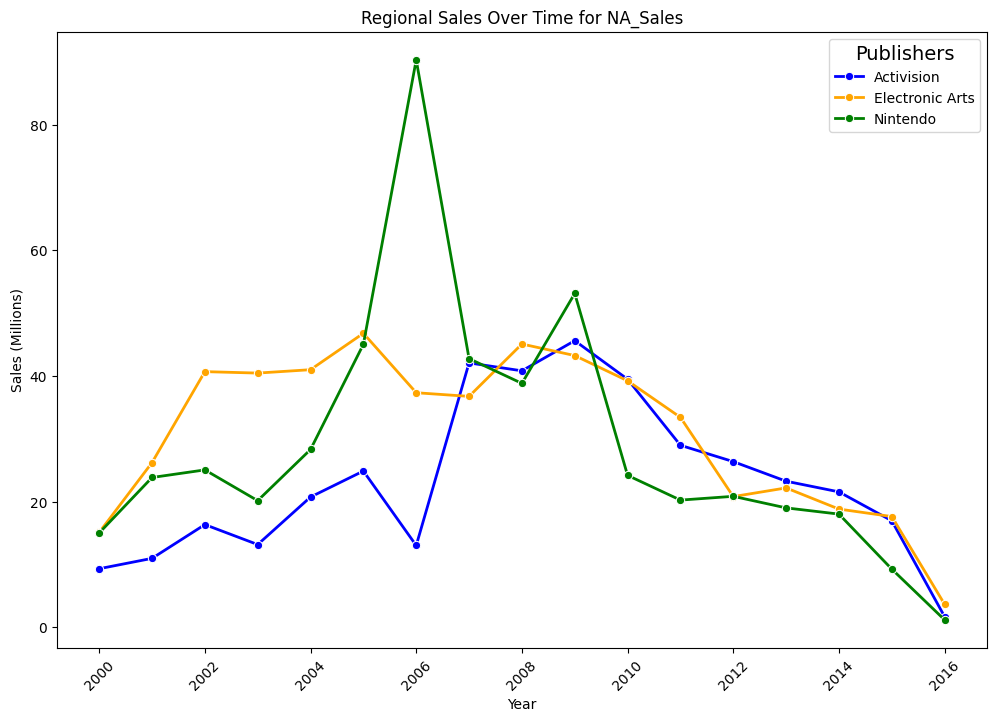

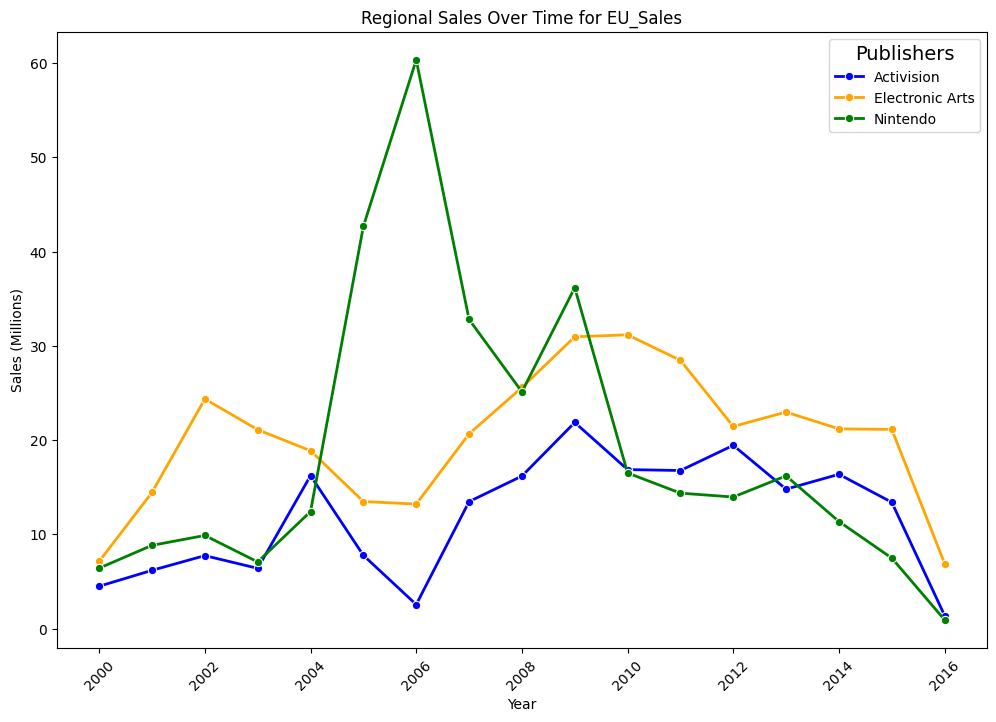

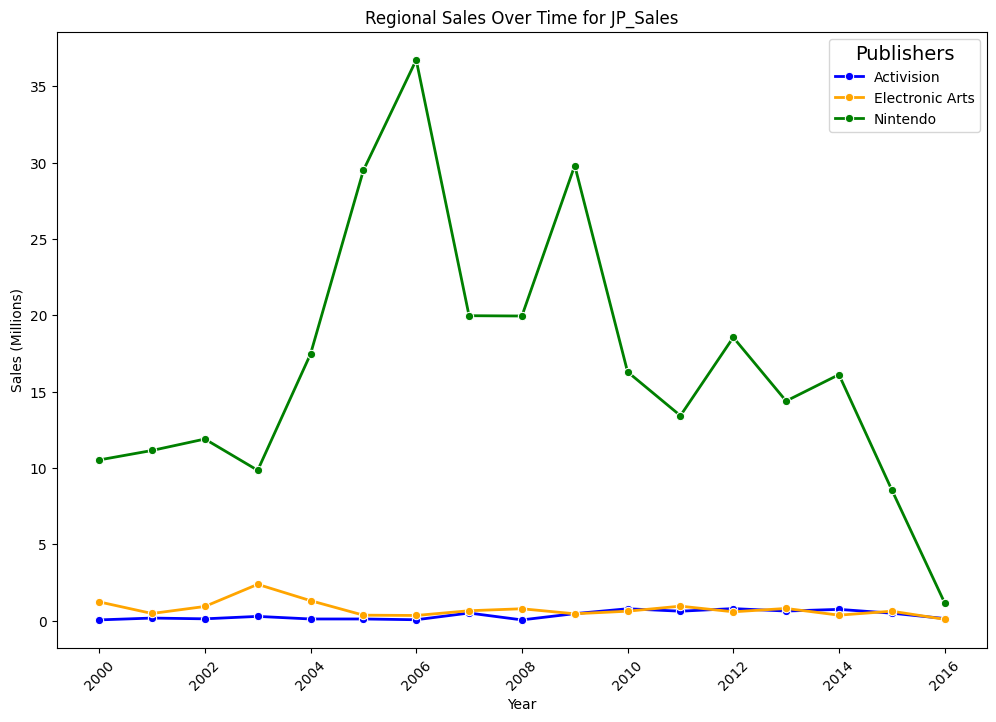

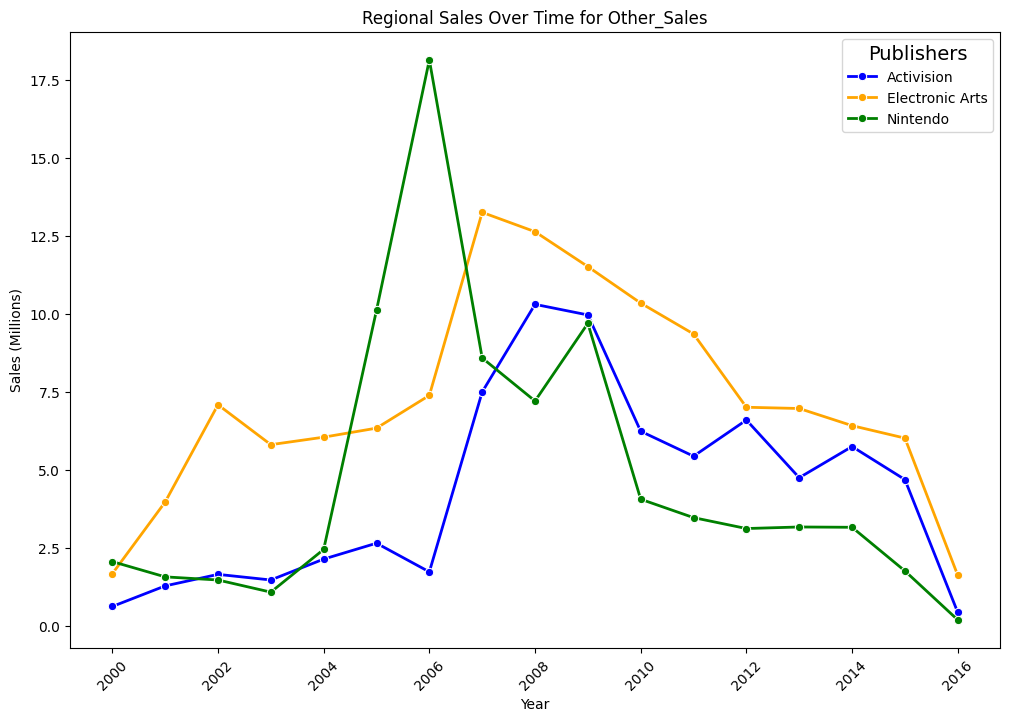

In [32]:
#regional sales over time data frame
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


data = df.copy()

# Define the top publishers based on total global sales
top_publishers = (
    data.groupby("Publisher")["Global_Sales"]
    .sum()
    .nlargest(3)
    .index
)

# Filter the data for the top publishers
regional_sales_columns = ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]
line_plot_data = data[data["Publisher"].isin(top_publishers)][["Publisher", "Year"] + regional_sales_columns]

# Ensure Year column is numeric and drop missing values
line_plot_data["Year"] = pd.to_numeric(line_plot_data["Year"], errors="coerce")
line_plot_data = line_plot_data.dropna(subset=["Year"])

# Filter data for years between 2000 and 2016
line_plot_data = line_plot_data[(line_plot_data["Year"] >= 2000) & (line_plot_data["Year"] <= 2016)]

# Group by Publisher and Year, summing sales for each year
line_plot_data = line_plot_data.groupby(["Publisher", "Year"]).sum().reset_index()

# Sort by Year to ensure proper order
line_plot_data = line_plot_data.sort_values(by="Year")

# Define custom colors for the publishers
custom_palette = {
    "Activision": "blue",
    "Electronic Arts": "orange",
    "Nintendo": "green"
}

# Create line plots with custom colors
for region in regional_sales_columns:
    plt.figure(figsize=(12, 8))
    sns.lineplot(
        data=line_plot_data,
        x="Year",
        y=region,
        hue="Publisher",
        palette=custom_palette,
        marker="o",
        linewidth=2,
    )
    plt.title(f"Regional Sales Over Time for {region}")
    plt.xlabel("Year")
    plt.ylabel("Sales (Millions)")
    plt.xticks(rotation=45)  # Rotate the year labels

    # Adjust legend
    legend = plt.legend(title="Publishers", loc="upper right")
    legend.get_title().set_fontsize(14)  # Set the font size for the title

    plt.show()

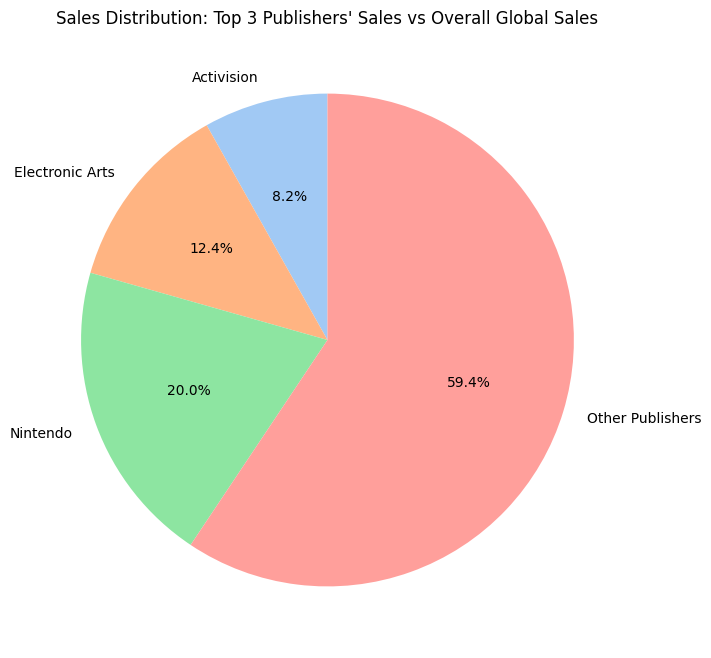

In [34]:
# Load the dataset
data = df.copy()

# Identify the top 3 publishers based on total global sales
top_publishers = (
    data.groupby("Publisher")["Global_Sales"]
    .sum()
    .nlargest(3)
    .index
)

# Calculate total global sales and top 3 publisher sales
total_global_sales = data["Global_Sales"].sum()
top_publishers_sales = (
    data[data["Publisher"].isin(top_publishers)].groupby("Publisher")["Global_Sales"].sum()
)

# Add "Other Publishers" category
other_sales = total_global_sales - top_publishers_sales.sum()
# Use pd.concat instead of append to combine the Series
sales_data = pd.concat([top_publishers_sales, pd.Series({"Other Publishers": other_sales})])


# Create the pie chart
plt.figure(figsize=(8, 8))
sales_data.plot.pie(
    autopct='%1.1f%%', startangle=90, labels=sales_data.index, colors=sns.color_palette("pastel")
)
plt.title("Sales Distribution: Top 3 Publishers' Sales vs Overall Global Sales")
plt.ylabel("")  # Remove y-axis label for better appearance
plt.show()

<ipython-input-35-ebf9ea34a80a>:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


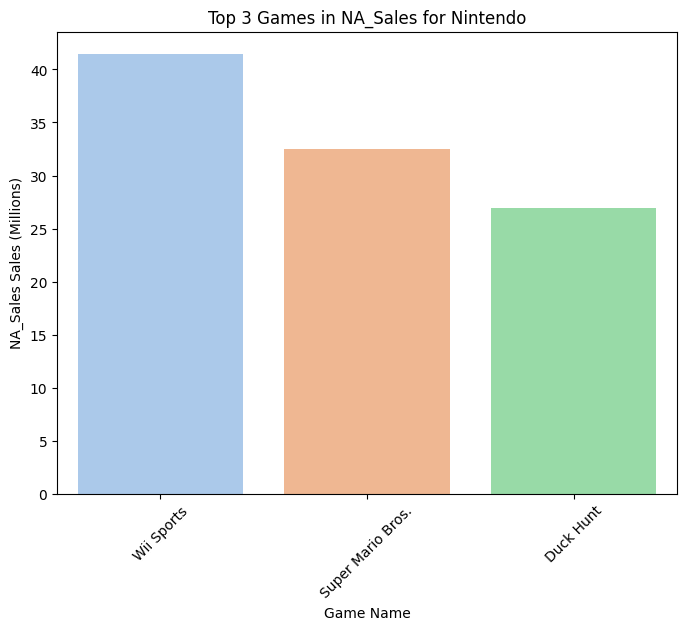

<ipython-input-35-ebf9ea34a80a>:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


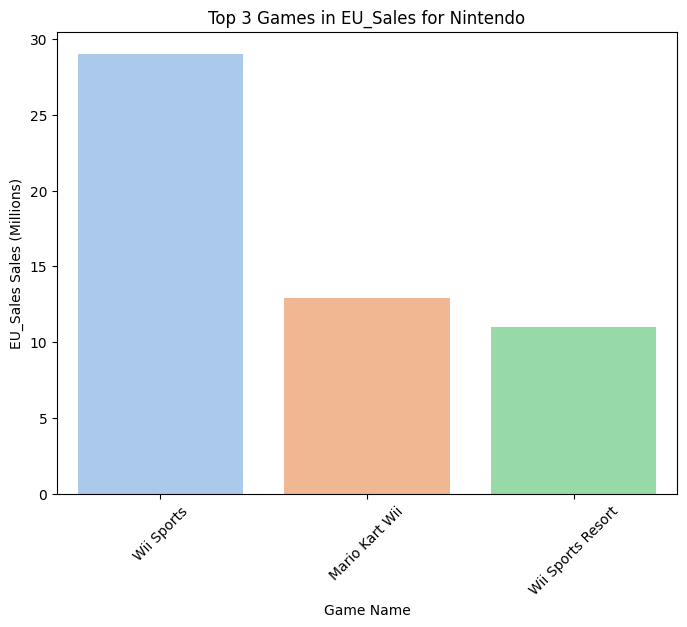

<ipython-input-35-ebf9ea34a80a>:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


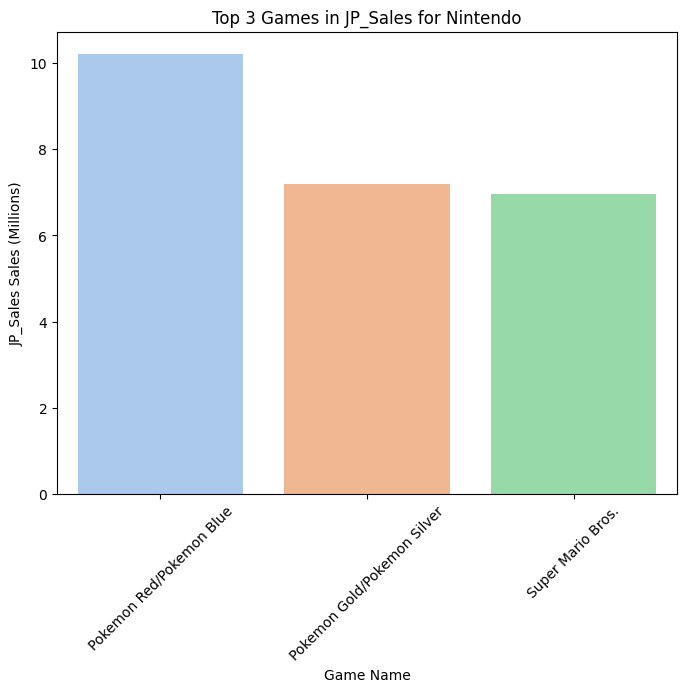

<ipython-input-35-ebf9ea34a80a>:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


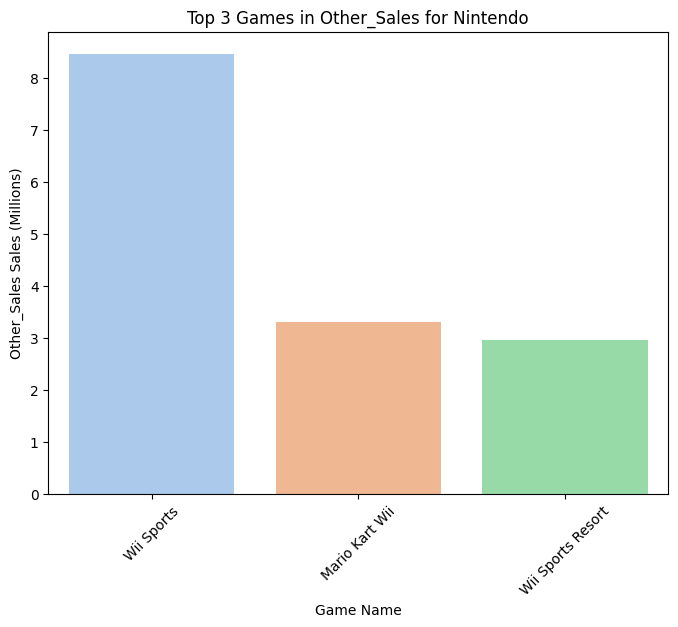

<ipython-input-35-ebf9ea34a80a>:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


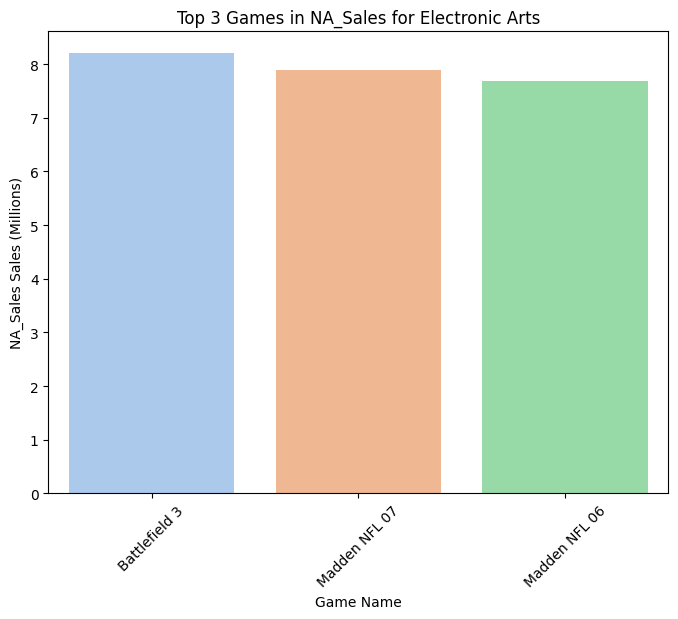

<ipython-input-35-ebf9ea34a80a>:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


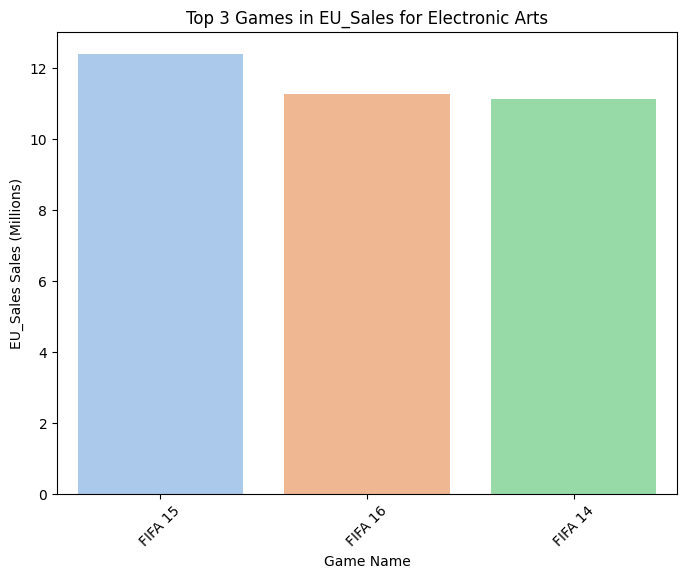

<ipython-input-35-ebf9ea34a80a>:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


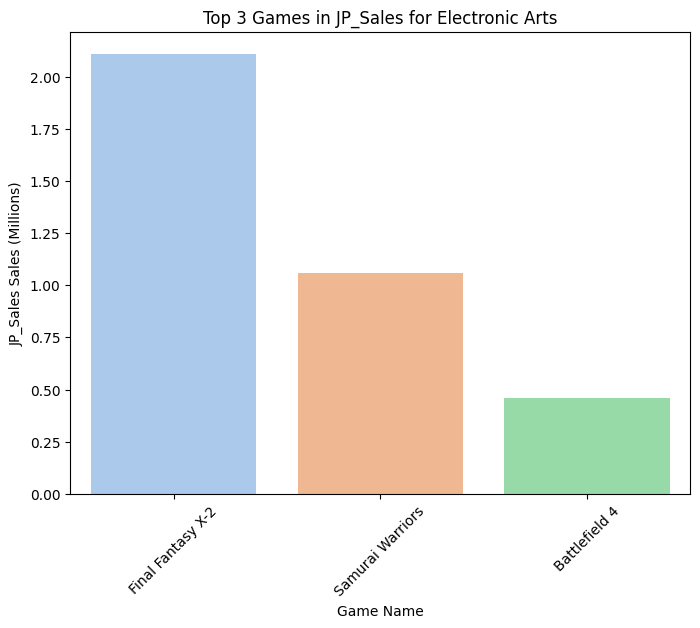

<ipython-input-35-ebf9ea34a80a>:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


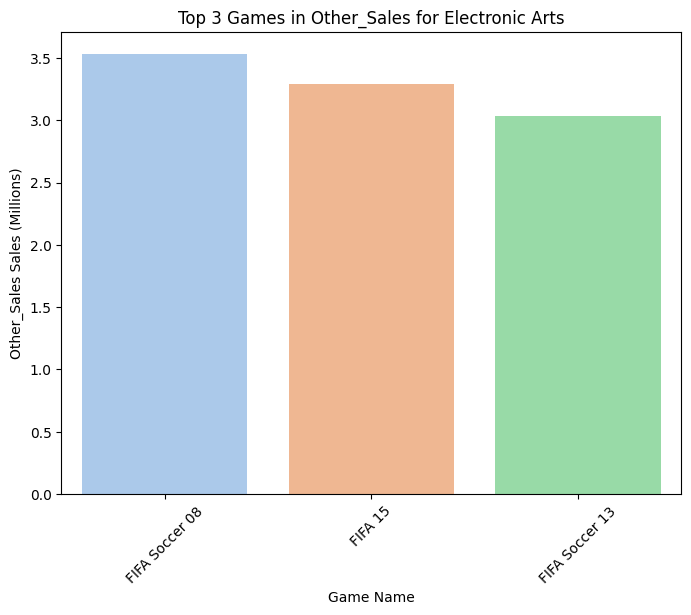

<ipython-input-35-ebf9ea34a80a>:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


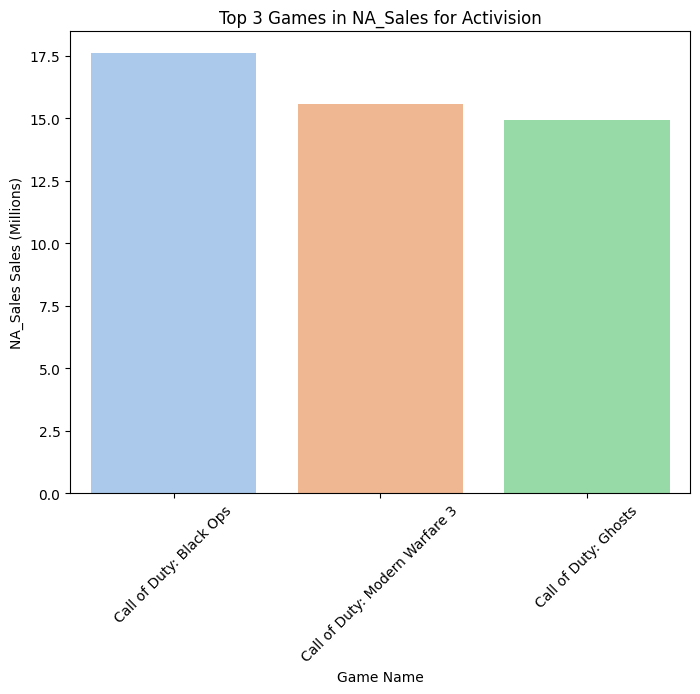

<ipython-input-35-ebf9ea34a80a>:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


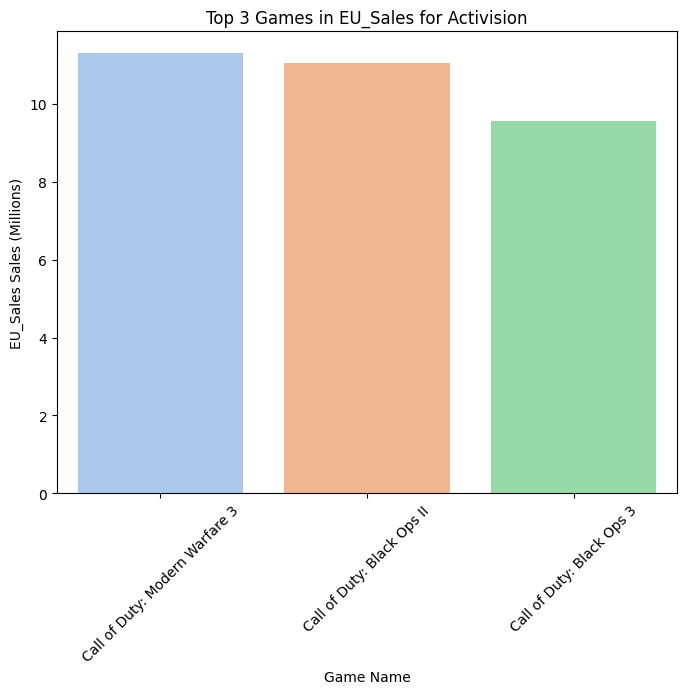

<ipython-input-35-ebf9ea34a80a>:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


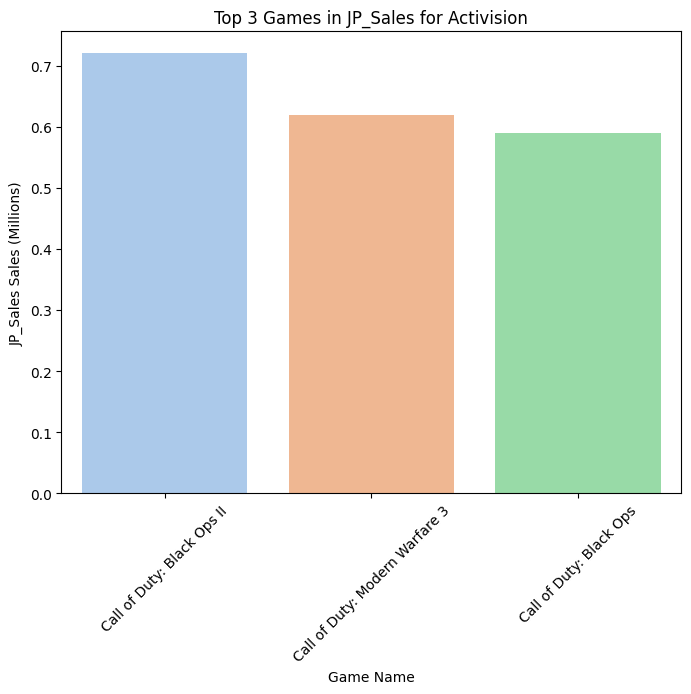

<ipython-input-35-ebf9ea34a80a>:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


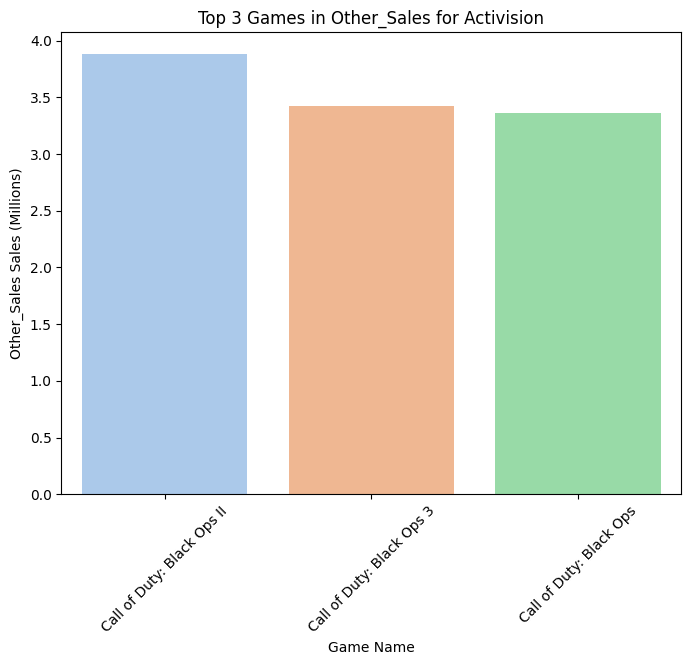

In [35]:
# Load the dataset
data = df.copy()


# Identify the top 3 publishers based on global sales
top_3_publishers = (
    data.groupby("Publisher")["Global_Sales"]
    .sum()
    .nlargest(3)
)

# Create an empty dictionary to store top 3 games per publisher and region
top_games_per_publisher_region = {}

# List of regions to analyze
regions = ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]

# Loop through each top publisher and region to calculate the top 3 games
for publisher in top_3_publishers.index:
    publisher_data = data[data["Publisher"] == publisher]
    top_games_per_region = {}

    for region in regions:
        top_games = (
            publisher_data.groupby("Name")[region]
            .sum()
            .reset_index()
            .sort_values(by=region, ascending=False)
            .head(3)
        )
        top_games_per_region[region] = top_games

    top_games_per_publisher_region[publisher] = top_games_per_region

# Combine results into a structured output
output = []
for publisher, regions_data in top_games_per_publisher_region.items():
    for region, games_data in regions_data.items():
        games_data["Publisher"] = publisher
        games_data["Region"] = region
        output.append(games_data)

# Combine all data into a single DataFrame
top_games_df = pd.concat(output, ignore_index=True)

# Isolate the data by each publisher
isolated_data = {}
for publisher in top_3_publishers.index:
    isolated_data[publisher] = top_games_df[top_games_df["Publisher"] == publisher]

# Visualize the data for each publisher
for publisher, data in isolated_data.items():
    for region in regions:
        region_data = data[data["Region"] == region]
        if not region_data.empty:
            plt.figure(figsize=(8, 6))
            sns.barplot(
                data=region_data,
                x="Name",
                y=region,
                palette="pastel"
            )
            plt.title(f"Top 3 Games in {region} for {publisher}")
            plt.xlabel("Game Name")
            plt.ylabel(f"{region} Sales (Millions)")
            plt.xticks(rotation=45)
            plt.show()